# Rede perceptron para reconhecer caracteres da base MNIST

O perceptron é o tipo mais simples de rede neural artificial feedforward. Nessa rede há varias entradas que se combinam em um único sinal de saída, que será zero ou um. Essa combinação é calculada como uma  soma ponderada da combinação das entradas, o bias nesse caso é representato por um outro termo que não depende da entrada. Após a soma ponderada é feita a modulação para chegar no Y = f(S).



### Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import copy
import platform
import random
import time

import tensorflow as tf
from tensorflow import keras

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import random_split, Subset

## Base de dados

Para montar uma rede neural é essencial ter uma base de dados. Vou importa-la do github, caso você prefira pode baixar anteriormente e extrai-la. Vamos ensina ao PyTorch como ler as pastas do computador e transformá-las em tensores para aí serem lidas pelo nosso modelo.

Aviso: Os nomes das imagens dentro da pasta do número não estão nomeados de 1 a n!

In [2]:
!wget https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
!tar xzf mnist.tgz


--2026-04-06 00:41:28--  https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/kyuz0/mnist-png/main/mnist.tgz [following]
--2026-04-06 00:41:28--  https://raw.githubusercontent.com/kyuz0/mnist-png/main/mnist.tgz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18294568 (17M) [application/octet-stream]
Saving to: ‘mnist.tgz.1’

mnist.tgz.1         100%[===================>]  17.45M  --.-KB/s    in 0.1s    

2026-04-06 00:41:28 (175 MB/s) - ‘mnist.tgz.1’ saved [18294568/18294568]



In [3]:
# def image_to_array(image_path):
#     image = Image.open(image_path)
#     transform = transforms.Compose([transforms.ToTensor()])
#     tensor_image = transform(image).squeeze(0)
#     return tensor_image.numpy()

# def array_to_image(array):
#     plt.imshow(array, cmap='gray')
#     plt.axis('off')
#     plt.show()

Para faxilitar e otimizar a programação vamos criar uma classe para o conjunto de dados MNIST. Ela irá herdar da Dataset da biblioteca torch.utils.data, assim é possível usar as funções pensadas para o dataset dessa classe da biblioteca.   Assim integramos o conjunto de dados MNIST diretamente às funcionalidades nativas da biblioteca, como o DataLoader.

In [4]:
class MNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Criamos uma lista com o caminho completo de cada imagem e com o rótulo correspondente (0 a 9)
        self.all_image_paths = []
        self.all_labels = []

        # Pega as pastas (0, 1, 2...) dentro do diretório raiz
        self.categories = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        for label_idx, category in enumerate(self.categories):
            category_path = os.path.join(root_dir, category)
            for img_name in os.listdir(category_path):
                self.all_image_paths.append(os.path.join(category_path, img_name))
                self.all_labels.append(label_idx)

    def __len__(self):
        return len(self.all_image_paths)

    def __getitem__(self, idx):
        img_path = self.all_image_paths[idx]
        label = self.all_labels[idx]

        image = Image.open(img_path).convert('L') # 'L' para escala de cinza

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        # Rótulo inteiro (0–9): mais rápido que one-hot + evita argmax no treino
        return image, torch.tensor(label, dtype=torch.long)


class MNISTInMemoryDataset(torch.utils.data.Dataset):
    """Carrega todas as imagens na RAM uma vez — evita ler o disco a cada época (muito mais rápido)."""

    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.all_image_paths = []
        self.all_labels = []
        self.categories = sorted(
            [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        )
        for label_idx, category in enumerate(self.categories):
            category_path = os.path.join(root_dir, category)
            for img_name in os.listdir(category_path):
                self.all_image_paths.append(os.path.join(category_path, img_name))
                self.all_labels.append(label_idx)
        n = len(self.all_labels)
        self._pixels = np.empty((n, 28, 28), dtype=np.uint8)
        for i, p in enumerate(self.all_image_paths):
            self._pixels[i] = np.array(Image.open(p).convert("L"), dtype=np.uint8)

    def __len__(self):
        return len(self.all_labels)

    def __getitem__(self, idx):
        image = Image.fromarray(self._pixels[idx], mode="L")
        label = self.all_labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        return image, torch.tensor(label, dtype=torch.long)

## Modelo

Agora irei contruir um modelo multilayer perceptron (MLP) simples para classificação de dígitos manuscritos do MNIST.
O modelo terá uma camada de entrada, uma camada oculta e uma camada de saída. Isso ocorre poque o MNIST é um conjunto de dados de imagens
de dígitos manuscritos, e um MLP é adequado para tarefas de classificação de imagens simples.

In [5]:
#Classe do Multi-Layer Perceptron (Nossa rede Neuural)
class PerceptronMNIST(nn.Module):
    def __init__(self, dropout_rate=0.25):
        super(PerceptronMNIST, self).__init__()
        # As imagens do MNIST são 28x28 pixels = 784 entradas
        self.fc1 = nn.Linear(28 * 28, 256)  # um pouco mais de capacidade → tende a melhor acurácia no MNIST
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc3 = nn.Linear(128, 10)       # Camada de Saída (10 dígitos: 0-9)

    def forward(self, x):
        # 1. Achatar a imagem: (B, 1, 28, 28) -> (B, 784)
        x = x.view(-1, 28 * 28)
        # 2. ReLU + normalização + dropout nas camadas ocultas
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        # 3. Saída (Logits)
        return self.fc3(x)

model = PerceptronMNIST(dropout_rate=0.25)

In [6]:
train_image_path = "mnist/training/"

# Normalização com média/desvio padrão clássicos do MNIST
# Augmentação mais leve = menos CPU por época (ainda ajuda na generalização)
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Carregando MNIST na RAM (treino — uma vez)...")
train_dataset_aug = MNISTInMemoryDataset(root_dir=train_image_path, transform=train_transform)
train_dataset_clean = MNISTInMemoryDataset(root_dir=train_image_path, transform=val_transform)
print(f"  {len(train_dataset_aug)} imagens prontas.")


Carregando MNIST na RAM (treino — uma vez)...
  60000 imagens prontas.


In [7]:
#for image, label in train_dataset:
#    plt.imshow(image.squeeze(0), cmap='gray')
#    print(f"Image shape: {image.shape}, Label: {label}")
#    break  # Remove this break to iterate through the entire dataset

## Trainamento

Vamos começar dividindo nossos dados em dois grupos: treino e validação. O primeiro serve para a rede aprender, e o segundo para conferirmos se ela não está apenas 'decorando' as imagens. Optei por reservar o conjunto de teste para uma demonstração humana, permitindo que o professor ou qualquer outra pessoa teste a rede com novos exemplos e veja o resultado em tempo real

In [8]:
dataset_size = len(train_dataset_aug)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

# Mantém os mesmos índices para treino/val, com transforms diferentes em cada split
indices = torch.randperm(dataset_size)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = Subset(train_dataset_aug, train_indices)
val_subset = Subset(train_dataset_clean, val_indices)

Em seguida, organizamos os dados em batches (lotes). Essa abordagem é muito mais eficiente porque permite que o hardware (especialmente a GPU) processe várias imagens simultaneamente através de cálculos matriciais paralelos. Além disso, os lotes tornam a atualização dos pesos da rede mais estável, evitando que o aprendizado oscile demais com o erro de uma única imagem isolada

In [9]:
# DataLoader otimizado: GPU usa batch maior, pin_memory e workers; CPU (especialmente Windows) evita custo de spawn
_use_cuda = torch.cuda.is_available()
BATCH_SIZE = 512 if _use_cuda else 64
_cpu = os.cpu_count() or 1
if _use_cuda:
    _num_workers = min(8, max(2, _cpu - 1))
    _pin_memory = True
else:
    _num_workers = 0 if platform.system() == "Windows" else min(4, max(1, _cpu - 1))
    _pin_memory = False

_common_kw = dict(
    batch_size=BATCH_SIZE,
    num_workers=_num_workers,
    pin_memory=_pin_memory,
    persistent_workers=_num_workers > 0,
)
train_loader = torch.utils.data.DataLoader(train_subset, shuffle=True, **_common_kw)
val_loader = torch.utils.data.DataLoader(val_subset, shuffle=False, **_common_kw)

print(f"Dispositivo de dados: {'CUDA' if _use_cuda else 'CPU'} | batch={BATCH_SIZE} | workers={_num_workers} | pin_memory={_pin_memory}")

Dispositivo de dados: CUDA | batch=512 | workers=2 | pin_memory=True


In [10]:
# Display de um batch de imagens e rótulos
# for images, labels in train_loader:
#     for i in range(BATCH_SIZE):  # Mostra as primeiras 4 imagens do batch
#         plt.subplot(4, 8, i+1) #Mudando o batch size teriamos de mudar isso
#         plt.imshow(images[i].squeeze(0), cmap='gray')
#         plt.title(f"Label: {labels[i].item()}", fontsize=8)
#         plt.axis('off')
#     plt.show()
#     break  # Remove this break para mostrar mais batches


Então vamos para parte mais importante ... o TREINAMENTO! Ele é um loop que

In [11]:
# 1. Define onde o "estudo" vai acontecer: na GPU (cuda) ou no processador (cpu)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")  # TF32 em GPUs Ampere+ — costuma acelerar treino

model = PerceptronMNIST(dropout_rate=0.25)
model.to(DEVICE)
if DEVICE.type == "cuda" and hasattr(torch, "compile"):
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("torch.compile ativo (PyTorch 2+).")
    except Exception as e:
        print(f"torch.compile ignorado: {e}")
print(f"Treinando em: {DEVICE}")
model

torch.compile ativo (PyTorch 2+).
Treinando em: cuda


OptimizedModule(
  (_orig_mod): PerceptronMNIST(
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.25, inplace=False)
    (fc3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [12]:
# Training loop: AMP, AdamW, label smoothing, medição de tempo
def train(model, train_loader, val_loader, epochs=10, lr=0.002, patience=3, min_lr=1e-5):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt_kw = {"lr": lr, "weight_decay": 1e-4}
    if DEVICE.type == "cuda":
        try:
            optimizer = torch.optim.AdamW(model.parameters(), fused=True, **opt_kw)
        except TypeError:
            optimizer = torch.optim.AdamW(model.parameters(), **opt_kw)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), **opt_kw)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=min_lr,
    )

    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    model.to(DEVICE)
    t0 = time.perf_counter()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        train_correct = 0
        train_total = 0

        for image, label in train_loader:
            image = image.to(DEVICE, non_blocking=True)
            label = label.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(image)
                loss = criterion(outputs, label)

            train_correct += (outputs.argmax(1) == label).sum().item()
            train_total += label.size(0)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            total_train_loss += loss.item()

        model.eval()
        val_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for image, label in val_loader:
                image = image.to(DEVICE, non_blocking=True)
                label = label.to(DEVICE, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=use_amp):
                    outputs = model(image)
                    loss = criterion(outputs, label)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += label.size(0)
                correct += (predicted == label).sum().item()

        val_accuracy = 100 * correct / total if total > 0 else 0
        train_accuracy = 100 * train_correct / train_total if train_total > 0 else 0
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_accuracy)
        history["val_acc"].append(val_accuracy)

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch+1}/{epochs}] | AMP={use_amp} | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping na época {epoch+1}.")
                break

    model.load_state_dict(best_state)
    elapsed = time.perf_counter() - t0
    history["train_seconds"] = elapsed
    history["device"] = str(DEVICE)
    print(f"Tempo total de treino: {elapsed:.2f} s em {DEVICE}")
    return model, history

In [13]:
# RUN: dados em RAM + batch maior na GPU aceleram; lr um pouco maior costuma convergir rápido no MNIST
model, history = train(model, train_loader, val_loader, epochs=20, lr=0.002, patience=3)


/tmp/ipykernel_1527/892568057.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self._pixels[idx], mode="L")
/tmp/ipykernel_1527/892568057.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self._pixels[idx], mode="L")
W0406 00:42:10.916000 1527 torch/_inductor/utils.py:1679] [0/1] Not enough SMs to use max_autotune_gemm mode
/tmp/ipykernel_1527/892568057.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self._pixels[idx], mode="L")
/tmp/ipykernel_1527/892568057.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self._pixels[idx], mode="L")


Epoch [1/20] | AMP=True | LR: 0.002000 | Train Loss: 0.7860 | Val Loss: 0.5235 | Train Acc: 83.36% | Val Acc: 92.46%
Epoch [2/20] | AMP=True | LR: 0.002000 | Train Loss: 0.5278 | Val Loss: 0.4427 | Train Acc: 92.63% | Val Acc: 95.31%
Epoch [3/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4857 | Val Loss: 0.4266 | Train Acc: 94.01% | Val Acc: 95.92%
Epoch [4/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4580 | Val Loss: 0.4386 | Train Acc: 95.04% | Val Acc: 95.54%
Epoch [5/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4463 | Val Loss: 0.4502 | Train Acc: 95.54% | Val Acc: 94.82%
Epoch [6/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4357 | Val Loss: 0.3889 | Train Acc: 95.82% | Val Acc: 97.11%
Epoch [7/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4261 | Val Loss: 0.3669 | Train Acc: 96.19% | Val Acc: 97.83%
Epoch [8/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4199 | Val Loss: 0.3807 | Train Acc: 96.38% | Val Acc: 97.27%
Epoch [9/20] | AMP=True | LR: 0.002000 | Train Loss: 0.4129 | Va

## Estudo do modelo

Gráficos de **perda** e **acurácia** (treino vs. validação), **tempo de treino** registrado em `history`, e teste com **uma imagem aleatória** do conjunto de teste.

Otimizações usadas: dados **em memória** (`MNISTInMemoryDataset`), **batch maior** na GPU, **AdamW** + *label smoothing*, **AMP** na GPU e opcionalmente **`torch.compile`**.

In [14]:
def plot_metricas_treino(history, figsize=(10, 4)):
    """Plota perda e acurácia de treino e validação por época."""
    n = len(history["train_loss"])
    if n == 0:
        print("Histórico vazio — rode o treino antes.")
        return
    epochs = range(1, n + 1)
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].plot(epochs, history["train_loss"], label="Treino", marker="o", markersize=4)
    axes[0].plot(epochs, history["val_loss"], label="Validação", marker="o", markersize=4)
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Perda")
    axes[0].set_title("Perda por época")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Treino", marker="o", markersize=4)
    axes[1].plot(epochs, history["val_acc"], label="Validação", marker="o", markersize=4)
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Acurácia (%)")
    axes[1].set_title("Acurácia por época")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 105)

    if "train_seconds" in history:
        ts = history["train_seconds"]
        dev = history.get("device", "")
        fig.suptitle(f"Tempo de treino: {ts:.2f} s | {dev}", y=1.02, fontsize=11)
        print(f"Tempo de treino: {ts:.2f} s | dispositivo: {dev}")

    plt.tight_layout()
    plt.show()


def amostra_aleatoria_teste(model, test_root="mnist/testing/", seed=None, show_plot=True):
    """Escolhe um exemplo aleatório do conjunto de teste, classifica e (opcional) mostra a imagem."""
    model.eval()
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)

    cache = getattr(amostra_aleatoria_teste, "_cache", {})
    if test_root not in cache:
        print(f"Carregando conjunto de teste na RAM: {test_root}")
        cache[test_root] = MNISTInMemoryDataset(root_dir=test_root, transform=val_transform)
    amostra_aleatoria_teste._cache = cache
    test_ds = cache[test_root]
    if len(test_ds) == 0:
        raise ValueError(f"Pasta de teste vazia ou inexistente: {test_root}")

    idx = random.randrange(len(test_ds))
    img_path = test_ds.all_image_paths[idx]
    image, label_tensor = test_ds[idx]
    true_label = int(label_tensor.item())

    x = image.unsqueeze(0).to(DEVICE, non_blocking=True)
    use_amp = DEVICE.type == "cuda"
    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=use_amp):
            pred = int(model(x).argmax(1).item())

    acertou = pred == true_label
    resultado = {
        "indice": idx,
        "caminho": img_path,
        "rotulo_verdadeiro": true_label,
        "rotulo_previsto": pred,
        "acertou": acertou,
    }

    if show_plot:
        t = image.squeeze().cpu()
        t = t * 0.3081 + 0.1307
        t = t.clamp(0, 1)
        plt.figure(figsize=(4, 4))
        plt.imshow(t.numpy(), cmap="gray")
        plt.title(
            f"Verdadeiro: {true_label} | Previsto: {pred}\n"
            f"{'Acerto' if acertou else 'Erro'}"
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return resultado

Tempo de treino: 304.97 s | dispositivo: cuda


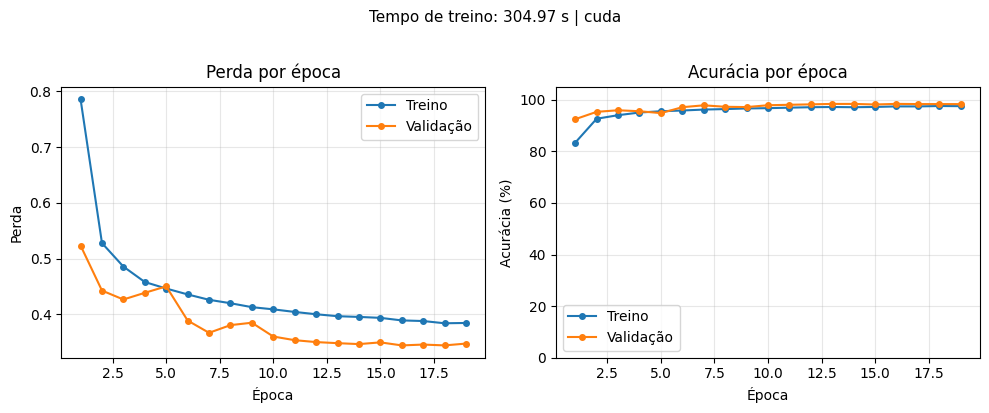

In [15]:
plot_metricas_treino(history)

Carregando conjunto de teste na RAM: mnist/testing/


/tmp/ipykernel_1527/892568057.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self._pixels[idx], mode="L")


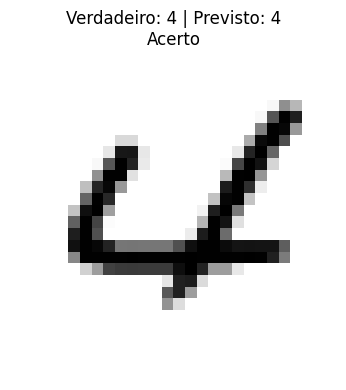

{'indice': 4225,
 'caminho': 'mnist/testing/4/9866.png',
 'rotulo_verdadeiro': 4,
 'rotulo_previsto': 4,
 'acertou': True}

In [16]:
# seed=None → amostra diferente a cada execução; use seed=42 para repetir o mesmo exemplo
amostra_aleatoria_teste(model, test_root="mnist/testing/", seed=None)

## Usando o Modelo

In [17]:
torch.save(model.state_dict(), "perceptron_mnist.pth")

In [18]:
def reconhece_digito(model, image_path):
    model.eval()  # Coloca o modelo em modo de avaliação
    image = Image.open(image_path).convert('L')  # Carrega a imagem e converte para escala de cinza
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    tensor_image = transform(image).unsqueeze(0).to(DEVICE)  # Adiciona dimensão de batch e move para o dispositivo

    with torch.no_grad():
        output = model(tensor_image)
        predicted_label = torch.argmax(output, dim=1).item()

    return predicted_label

In [19]:
reconhece_digito(model, "mnist/testing/4/1010.png")

4